# RAPTOR — 클러스터링 기반 계층적 RAG

## 학습 목표

이 노트북을 마치면 다음을 할 수 있어요:

- **RAPTOR** 논문의 핵심인 **의미적 클러스터링** 기반 트리 구조 이해하기
- **UMAP** 차원 축소와 **GMM** 클러스터링으로 유사한 청크 자동 그룹화하기
- 재귀적 임베딩-클러스터링-요약 파이프라인으로 **다단계 트리** 구축하기
- 원본 + 다단계 요약을 통합한 벡터스토어에서 **추상화 수준별 검색** 수행하기

## 사전 지식

- 04-RAPTOR.ipynb의 간소화된 RAPTOR 개념
- 벡터스토어와 임베딩의 기본 개념

---

```mermaid
flowchart TD
    D[원본 문서]:::input --> S[텍스트 분할]:::process
    S --> L0[레벨 0: 원본 청크]:::process
    L0 --> E0[임베딩 생성]:::process
    E0 --> U0[UMAP 차원 축소]:::process
    U0 --> G0[GMM 클러스터링]:::process
    G0 --> SUM0[클러스터별 LLM 요약]:::process
    SUM0 --> L1[레벨 1 요약]:::output

    L1 --> E1[임베딩 → UMAP → GMM]:::process
    E1 --> SUM1[클러스터별 요약]:::process
    SUM1 --> L2[레벨 2 요약]:::output

    L0 --> VS[(통합 벡터스토어)]:::storage
    L1 --> VS
    L2 --> VS
    Q[사용자 질문]:::input --> VS
    VS --> R[레벨별 자동 검색]:::process
    R --> A[답변]:::output

    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef output fill:#fff3cd,stroke:#ffc107,color:#856404
    classDef storage fill:#e2d5f1,stroke:#6f42c1,color:#3d1f6e
```

> 🎯 **강의 포인트**: 04-RAPTOR.ipynb에서는 청크를 순서대로 5개씩 묶었어요. 이번 노트북에서는 RAPTOR 논문 원본처럼 **의미적 클러스터링**으로 청크를 묶어요. 문서 내 위치가 아닌 임베딩 유사도로 그룹화한다는 점이 핵심입니다.

> 🔑 **핵심 개념**: RAPTOR는 3단계 파이프라인을 재귀적으로 반복해요: **임베딩 → 클러스터링 → 요약**. 각 반복에서 이전 레벨의 요약이 다음 레벨의 입력이 되어 점점 더 추상적인 요약 트리가 만들어져요.

In [19]:
from dotenv import load_dotenv
load_dotenv()

True

In [20]:
!uv add umap-learn

Resolved 431 packages in 15ms
Audited 401 packages in 100ms


In [21]:
import os
import warnings
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
warnings.filterwarnings("ignore")

from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import umap
from sklearn.mixture import GaussianMixture

from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import PyMuPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough

RANDOM_SEED = 42

## 1. 문서 로드 및 텍스트 분할

In [22]:
# 문서 로드
loader = PyMuPDFLoader("./data/2026_gov.pdf")
docs = loader.load()

# 청크 분할
text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
chunks = text_splitter.split_documents(docs[41:95])
leaf_texts = [chunk.page_content for chunk in chunks]

print(f"레벨 0 청크: {len(leaf_texts)}개")
print(f"평균 크기: {np.mean([len(t) for t in leaf_texts]):.0f}자")

레벨 0 청크: 88개
평균 크기: 364자


## 2. 클러스터링 함수 정의

RAPTOR의 클러스터링 파이프라인은 4단계로 구성돼요:

| 단계 | 기법 | 역할 |
|------|------|------|
| 차원 축소 | **UMAP** | 고차원 임베딩을 저차원으로 축소 |
| 최적 k 결정 | **BIC** | 데이터에 맞는 클러스터 수를 자동 결정 |
| 클러스터링 | **GMM** | 소프트 클러스터링 (1개 청크가 여러 클러스터에 소속 가능) |
| 계층화 | **전역+로컬** | 전역 클러스터 내에서 다시 로컬 클러스터링 |

> 💡 **실무 팁**: GMM의 `threshold`가 낮을수록(예: 0.1) 하나의 청크가 여러 클러스터에 속할 수 있어서 내용 누락이 줄어들어요.

In [23]:
# ---------------------------------------------------
# UMAP 차원 축소
# ---------------------------------------------------

def global_cluster_embeddings(
    embeddings: np.ndarray, dim: int,
    n_neighbors: Optional[int] = None, metric: str = "cosine",
) -> np.ndarray:
    """전역 차원 축소: 전체 데이터의 큰 구조를 파악해요."""
    if n_neighbors is None:
        n_neighbors = int((len(embeddings) - 1) ** 0.5)
    return umap.UMAP(
        n_neighbors=n_neighbors, n_components=dim, metric=metric
    ).fit_transform(embeddings)


def local_cluster_embeddings(
    embeddings: np.ndarray, dim: int,
    num_neighbors: int = 10, metric: str = "cosine",
) -> np.ndarray:
    """로컬 차원 축소: 특정 클러스터 내에서 세밀한 구조를 발견해요."""
    return umap.UMAP(
        n_neighbors=num_neighbors, n_components=dim, metric=metric
    ).fit_transform(embeddings)

In [24]:
# ---------------------------------------------------
# BIC 기반 최적 클러스터 수 + GMM 클러스터링
# ---------------------------------------------------

def get_optimal_clusters(
    embeddings: np.ndarray, max_clusters: int = 50, random_state: int = RANDOM_SEED
) -> int:
    """BIC 점수가 가장 낮은 클러스터 수를 반환해요."""
    max_clusters = min(max_clusters, len(embeddings))
    n_clusters = np.arange(1, max_clusters)
    bics = []
    for n in n_clusters:
        gm = GaussianMixture(n_components=n, random_state=random_state)
        gm.fit(embeddings)
        bics.append(gm.bic(embeddings))
    return n_clusters[np.argmin(bics)]


def GMM_cluster(embeddings: np.ndarray, threshold: float, random_state: int = 0):
    """소프트 클러스터링: threshold 초과 확률의 클러스터에 할당해요."""
    n_clusters = get_optimal_clusters(embeddings)
    gm = GaussianMixture(n_components=n_clusters, random_state=random_state)
    gm.fit(embeddings)
    probs = gm.predict_proba(embeddings)
    labels = [np.where(prob > threshold)[0] for prob in probs]
    return labels, n_clusters

In [25]:
# ---------------------------------------------------
# 계층적 클러스터링: 전역 → 로컬 2단계
# ---------------------------------------------------

def perform_clustering(
    embeddings: np.ndarray, dim: int, threshold: float,
) -> List[np.ndarray]:
    if len(embeddings) <= dim + 1:
        return [np.array([0]) for _ in range(len(embeddings))]

    # 전역 차원 축소 + 클러스터링
    reduced_global = global_cluster_embeddings(embeddings, dim)
    global_clusters, n_global = GMM_cluster(reduced_global, threshold)

    all_local_clusters = [np.array([]) for _ in range(len(embeddings))]
    total_clusters = 0

    for i in range(n_global):
        # 현재 전역 클러스터에 속하는 임베딩 추출
        mask = np.array([i in gc for gc in global_clusters])
        cluster_embs = embeddings[mask]

        if len(cluster_embs) == 0:
            continue
        if len(cluster_embs) <= dim + 1:
            local_clusters = [np.array([0]) for _ in cluster_embs]
            n_local = 1
        else:
            # 로컬 차원 축소 + 클러스터링
            reduced_local = local_cluster_embeddings(cluster_embs, dim)
            local_clusters, n_local = GMM_cluster(reduced_local, threshold)

        for j in range(n_local):
            local_embs = cluster_embs[np.array([j in lc for lc in local_clusters])]
            indices = np.where((embeddings == local_embs[:, None]).all(-1))[1]
            for idx in indices:
                all_local_clusters[idx] = np.append(
                    all_local_clusters[idx], j + total_clusters
                )
        total_clusters += n_local

    return all_local_clusters

## 3. 클러스터링 실행 및 시각화

> 🎯 **강의 포인트**: 여기서는 시각화를 위해 2차원으로 축소해요. 실제 RAPTOR 트리 구축에서는 10차원을 사용해요.

In [26]:
# ---------------------------------------------------
# 임베딩 생성 + 2D 시각화용 UMAP
# ---------------------------------------------------
embedding_model = OpenAIEmbeddings(model="text-embedding-3-small")
text_embeddings_np = np.array(embedding_model.embed_documents(leaf_texts))
print(f"임베딩 shape: {text_embeddings_np.shape}")

# 2D 축소 (시각화용)
reduced_2d = global_cluster_embeddings(text_embeddings_np, dim=2)

임베딩 shape: (88, 1536)


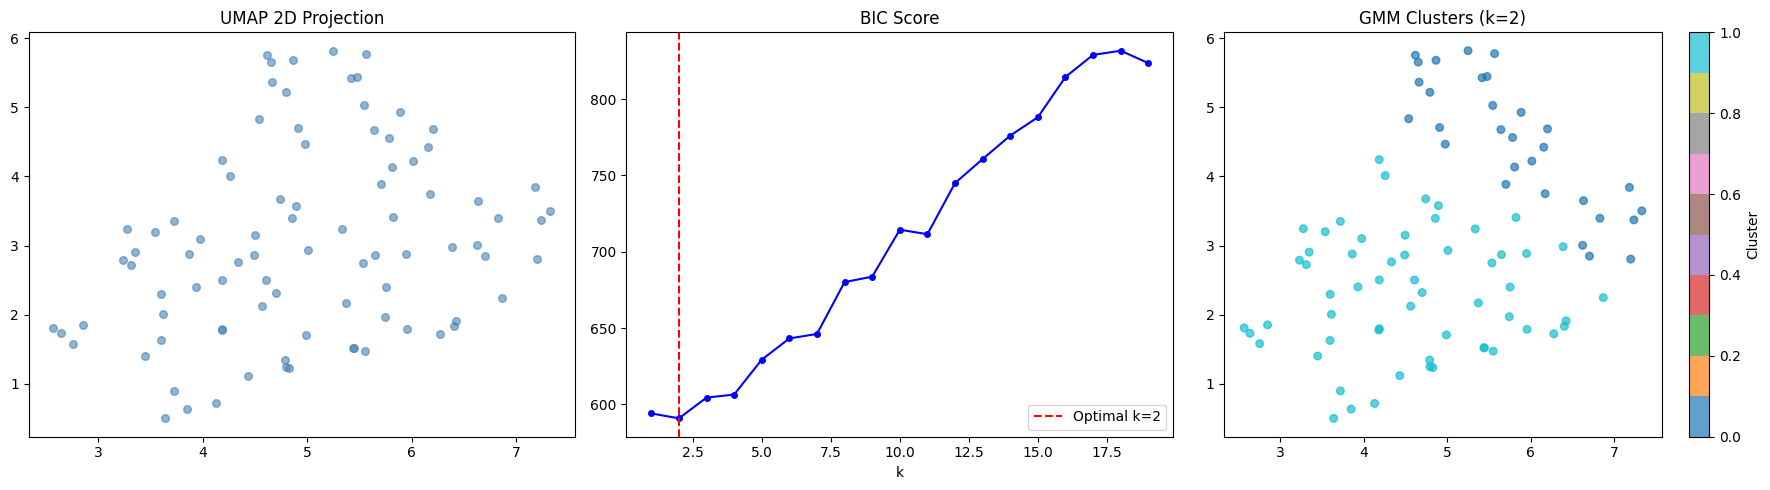

  Cluster 0: 30개
  Cluster 1: 58개


In [27]:
# ---------------------------------------------------
# BIC 곡선 + 클러스터 산점도 시각화
# ---------------------------------------------------
max_k = min(20, len(reduced_2d))
bics = []
for n in range(1, max_k):
    gm = GaussianMixture(n_components=n, random_state=RANDOM_SEED)
    gm.fit(reduced_2d)
    bics.append(gm.bic(reduced_2d))
optimal_k = np.argmin(bics) + 1

gm = GaussianMixture(n_components=optimal_k, random_state=RANDOM_SEED)
gm.fit(reduced_2d)
cluster_labels = gm.predict(reduced_2d)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(reduced_2d[:, 0], reduced_2d[:, 1], alpha=0.6, s=30, c="steelblue")
axes[0].set_title("UMAP 2D Projection")

axes[1].plot(range(1, max_k), bics, "bo-", markersize=4)
axes[1].axvline(x=optimal_k, color="r", linestyle="--", label=f"Optimal k={optimal_k}")
axes[1].set_title("BIC Score")
axes[1].set_xlabel("k")
axes[1].legend()

scatter = axes[2].scatter(reduced_2d[:, 0], reduced_2d[:, 1], c=cluster_labels, cmap="tab10", alpha=0.7, s=30)
axes[2].set_title(f"GMM Clusters (k={optimal_k})")
plt.colorbar(scatter, ax=axes[2], label="Cluster")

plt.tight_layout()
plt.show()

for i in range(optimal_k):
    print(f"  Cluster {i}: {(cluster_labels == i).sum()}개")

## 4. 재귀적 트리 구축

클러스터링 함수들을 조합해서 **임베딩 → 클러스터링 → 요약**을 재귀적으로 반복해요.

> 🔑 **핵심 개념**: `embed_cluster_summarize_texts`가 한 레벨의 처리를 담당하고, `recursive_embed_cluster_summarize`가 이것을 재귀적으로 반복해요. 클러스터가 1개만 남거나 최대 레벨에 도달하면 종료해요.

In [28]:
# ---------------------------------------------------
# 모델 + 헬퍼 함수
# ---------------------------------------------------
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)


def embed(texts):
    return np.array(embedding_model.embed_documents(texts))


def embed_cluster_texts(texts):
    text_embeddings_np = embed(texts)
    cluster_labels = perform_clustering(text_embeddings_np, 10, 0.1)
    df = pd.DataFrame()
    df["text"] = texts
    df["embd"] = list(text_embeddings_np)
    df["cluster"] = cluster_labels
    return df


def fmt_txt(df):
    return "\n---\n".join(df["text"].tolist())

In [29]:
# ---------------------------------------------------
# 임베딩 + 클러스터링 + 요약 통합 함수
# ---------------------------------------------------

def embed_cluster_summarize_texts(texts, level):
    # 임베딩 + 클러스터링
    df_clusters = embed_cluster_texts(texts)

    # 소프트 클러스터링 확장 (1개 데이터가 여러 클러스터에 소속 가능)
    expanded_list = []
    for _, row in df_clusters.iterrows():
        for cluster in row["cluster"]:
            expanded_list.append({"text": row["text"], "embd": row["embd"], "cluster": cluster})
    expanded_df = pd.DataFrame(expanded_list)
    all_clusters = expanded_df["cluster"].unique()
    print(f"  Level {level}: {len(all_clusters)} clusters")

    # 클러스터별 LLM 요약
    summary_prompt = PromptTemplate.from_template(
        """다음 문서들의 핵심 내용을 하나의 일관된 요약으로 통합하세요.

문서:
{context}

통합 요약:"""
    )
    chain = summary_prompt | llm | StrOutputParser()

    summaries = []
    for i in all_clusters:
        df_cluster = expanded_df[expanded_df["cluster"] == i]
        summaries.append(chain.invoke({"context": fmt_txt(df_cluster)}))

    df_summary = pd.DataFrame({
        "summaries": summaries,
        "level": [level] * len(summaries),
        "cluster": list(all_clusters),
    })
    return df_clusters, df_summary

In [30]:
# ---------------------------------------------------
# 재귀적 트리 구축
# ---------------------------------------------------

def recursive_embed_cluster_summarize(texts, level=1, n_levels=3):
    results = {}
    df_clusters, df_summary = embed_cluster_summarize_texts(texts, level)
    results[level] = (df_clusters, df_summary)

    unique_clusters = df_summary["cluster"].nunique()
    if level < n_levels and unique_clusters > 1:
        new_texts = df_summary["summaries"].tolist()
        results.update(recursive_embed_cluster_summarize(new_texts, level + 1, n_levels))

    return results

In [31]:
# 트리 구축 실행
results = recursive_embed_cluster_summarize(leaf_texts, level=1, n_levels=3)
print(f"\n✅ 트리 구축 완료: {len(results)}개 레벨")

  Level 1: 14 clusters
  Level 2: 3 clusters
  Level 3: 1 clusters

✅ 트리 구축 완료: 3개 레벨


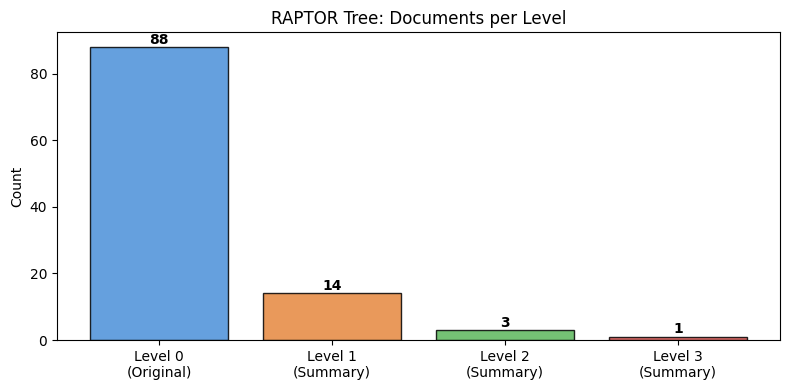


Level 1 샘플: 2026년부터 시행되는 주요 금융 및 세제 개편안은 다음과 같습니다. 

1. **세금 및 비과세 조정**: 농협, 수협, 산림조합의 조합원 및 총급여 7천만원 이하의 준조합원에 대한 예탁금과 출자금의 이자 및 배당...

Level 2 샘플: 2026년 1월 1일부터 시행되는 주요 금융 및 세제 개편안은 다양한 분야에서 세금 부담을 경감하고, 청년층과 중소기업, 사회적 기업을 지원하며, 지역 균형 발전을 도모하는 내용을 포함하고 있습니다. 

주요 내용은...

Level 3 샘플: 2026년 1월 1일부터 시행되는 한국의 주요 금융 및 세제 개편안은 세금 부담 경감, 청년층 및 중소기업 지원, 자녀 양육 부담 완화, 그리고 지역 균형 발전을 목표로 하고 있습니다. 

주요 내용은 다음과 같습니...


In [32]:
# ---------------------------------------------------
# 트리 레벨별 통계 시각화
# ---------------------------------------------------
level_names = ["Level 0\n(Original)"]
level_counts = [len(leaf_texts)]
colors = ["#4a90d9", "#e6873e", "#5cb85c", "#d9534f"]

for level in sorted(results.keys()):
    n = len(results[level][1])
    level_names.append(f"Level {level}\n(Summary)")
    level_counts.append(n)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(level_names, level_counts, color=colors[:len(level_names)], edgecolor="black", alpha=0.85)
for bar, count in zip(bars, level_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, str(count), ha='center', fontweight='bold')
ax.set_title("RAPTOR Tree: Documents per Level")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

# 요약 샘플
for level in sorted(results.keys()):
    s = results[level][1]["summaries"].iloc[0]
    print(f"\nLevel {level} 샘플: {s[:120]}...")

## 5. 벡터스토어 + RAG 체인

In [33]:
# ---------------------------------------------------
# 모든 레벨 통합 벡터스토어
# ---------------------------------------------------
all_texts = leaf_texts.copy()
for level in sorted(results.keys()):
    all_texts.extend(results[level][1]["summaries"].tolist())

vectorstore = FAISS.from_texts(texts=all_texts, embedding=embedding_model)
retriever = vectorstore.as_retriever(search_kwargs={"k": 5})

print(f"✅ 벡터스토어: 레벨 0({len(leaf_texts)}) + 요약({len(all_texts) - len(leaf_texts)}) = {len(all_texts)}개")

✅ 벡터스토어: 레벨 0(88) + 요약(18) = 106개


In [34]:
# ---------------------------------------------------
# RAPTOR RAG 체인
# ---------------------------------------------------
raptor_prompt = PromptTemplate.from_template(
    """문맥을 참고하여 질문에 답하세요.

문맥:
{context}

질문: {question}

답변:"""
)

raptor_chain = (
    {"context": retriever, "question": RunnablePassthrough()}
    | raptor_prompt
    | llm
    | StrOutputParser()
)
print("✅ RAPTOR RAG 체인 생성 완료")

✅ RAPTOR RAG 체인 생성 완료


## 6. 테스트: 추상화 수준별 질문

> 🎯 **강의 포인트**: 검색 결과에서 [원본]/[요약] 태그를 확인하세요. 개괄적 질문에는 요약이, 세부 질문에는 원본이 더 많이 검색된다는 점을 강조하세요.

In [35]:
# 질문 1: 개괄적 질문
q1 = "이 문서의 전반적인 주제는 무엇인가요?"
print(f"질문: {q1}")
print("=" * 60)

retrieved = retriever.invoke(q1)
print("\n검색된 문서:")
for i, doc in enumerate(retrieved, 1):
    tag = "요약" if doc.page_content not in leaf_texts else "원본"
    print(f"  [{i}] [{tag}] {doc.page_content[:100]}...")

print(f"\n답변:\n{raptor_chain.invoke(q1)}")

질문: 이 문서의 전반적인 주제는 무엇인가요?

검색된 문서:
  [1] [요약] 2026년 1월 1일부터 시행되는 주요 금융 및 세제 개편안은 다양한 분야에서 세금 부담을 경감하고, 청년층과 중소기업, 사회적 기업을 지원하며, 지역 균형 발전을 도모하는 내용을...
  [2] [요약] 2026년 1월 1일부터 시행되는 한국의 주요 금융 및 세제 개편안은 세금 부담 경감, 청년층 및 중소기업 지원, 자녀 양육 부담 완화, 그리고 지역 균형 발전을 목표로 하고 있습...
  [3] [원본] 개정내용은 2026년 1월 1일 이후 가입하는 분부터 적용됩니다.
상호금융 예탁금ㆍ출자금 비과세 적용기한 연장 및 적용범위 합리화 
추진배경
농ㆍ어ㆍ임업인 지원 및 과세형평 제고
...
  [4] [원본] 20
영상콘텐츠 세제지원 확대
재정경제부
www.moef.go.kr
영상콘텐츠산업의 글로벌 경쟁력 지원을 위하여 영상콘텐츠 제작비용 세액공제의 기본공제율이 
추가공제율과 일치되도록...
  [5] [원본] 2
금융·재정·조세
제 1 장
통합고용세액공제 공제액 구조 개편 및 사후관리 합리화
시행일: 2026년 1월 1일
자세한 내용은p.008
• 장기고용 유인강화 및 납세 협력 비용...

답변:
이 문서의 전반적인 주제는 2026년 1월 1일부터 시행되는 한국의 주요 금융 및 세제 개편안에 대한 내용입니다. 이 개편안은 세금 부담 경감, 청년층 및 중소기업 지원, 자녀 양육 부담 완화, 그리고 지역 균형 발전을 목표로 하고 있으며, 다양한 세제 조정 및 지원 방안이 포함되어 있습니다.


In [36]:
# 질문 2: 세부적 질문
q2 = "영상콘텐츠 제작비용 세액공제의 구체적인 공제율은?"
print(f"질문: {q2}")
print("=" * 60)

retrieved = retriever.invoke(q2)
print("\n검색된 문서:")
for i, doc in enumerate(retrieved, 1):
    tag = "요약" if doc.page_content not in leaf_texts else "원본"
    print(f"  [{i}] [{tag}] {doc.page_content[:100]}...")

print(f"\n답변:\n{raptor_chain.invoke(q2)}")

질문: 영상콘텐츠 제작비용 세액공제의 구체적인 공제율은?

검색된 문서:
  [1] [원본] 20
영상콘텐츠 세제지원 확대
재정경제부
www.moef.go.kr
영상콘텐츠산업의 글로벌 경쟁력 지원을 위하여 영상콘텐츠 제작비용 세액공제의 기본공제율이 
추가공제율과 일치되도록...
  [2] [원본] 2
금융·재정·조세
제 1 장
통합고용세액공제 공제액 구조 개편 및 사후관리 합리화
시행일: 2026년 1월 1일
자세한 내용은p.008
• 장기고용 유인강화 및 납세 협력 비용...
  [3] [원본] 주요내용
웹툰콘텐츠 제작비용에 대해 소득세·법인세 세액공제 신설
시행일
2026년 1월 1일 이후 발생하는 비용 분부터 적용
재정경제부 누리집>보도자료>2025년 세제개편안 발표(...
  [4] [원본] 9
2026년부터 이렇게 달라집니다
웹툰콘텐츠 제작비용 세액공제 신설 
재정경제부
www.moef.go.kr
웹툰콘텐츠산업의 글로벌 경쟁력 지원을 위하여 웹툰콘텐츠 제작비용에 대한...
  [5] [요약] 2026년 1월 1일부터 시행되는 새로운 세제 개편안은 통합고용세액공제의 공제액 구조 개편, 웹툰 및 영상콘텐츠 제작비용에 대한 세액공제 신설, 그리고 무주택 주말부부에 대한 월세...

답변:
영상콘텐츠 제작비용 세액공제의 구체적인 공제율은 대기업과 중견기업은 10%, 중소기업은 15%입니다.


---

## 핵심 요약

| 항목 | 04-RAPTOR (간소화) | 04.1-RAPTOR-Clustering (이 노트북) |
|------|---------------------|-----------------------------|
| 그룹화 | 순서대로 5개씩 | UMAP + GMM 의미적 클러스터링 |
| 클러스터 수 | 고정 (N/5) | BIC로 자동 결정 |
| 멤버십 | 하드 (1개 그룹) | 소프트 (다중 클러스터 가능) |
| 트리 레벨 | 2레벨 고정 | 3+ 레벨 재귀 |
| 요약 품질 | 무관한 청크 혼합 | 유사 청크 통합으로 높음 |

### 다음 노트북 예고

**05-Web-Summarization** — Map-Reduce 패턴으로 웹 문서를 대규모로 요약하고, 원본과 요약을 통합 검색하는 방법을 배워요.